In [11]:
import cv2
import nibabel as nib
import pandas as pd
from tqdm import tqdm
import numpy as np
import os
import matplotlib.pyplot as plt
import torch
import glob
from torch.utils.data import Dataset, DataLoader
from monai.transforms import (
    Compose, 
    ResizeWithPadOrCropd,
    EnsureChannelFirstd,
    NormalizeIntensityd,
    HistogramNormalized,
    ScaleIntensityRangePercentilesd
)
from sklearn.model_selection import train_test_split
from image import Image

In [12]:
description = pd.read_csv("../data/train_series_descriptions.csv")

In [13]:
description.head()

,study_id,series_id,series_description
0,4003253,702807833,Sagittal T2/STIR
1,4003253,1054713880,Sagittal T1
2,4003253,2448190387,Axial T2
3,4646740,3201256954,Axial T2
4,4646740,3486248476,Sagittal T1


In [23]:
path = "../../TotalSpineSeg"
# path = "../../duke/public/rsna_challenge/totalspineseg_output"
vol_paths = glob.glob(path + "/output/input/sub*T2w*.nii.gz") #os.listdir(path + "/data")

print(len(vol_paths))
# y = "sub-4646740_acq-sag_rec-3666319702_T2w.nii.gz" 
y = np.random.choice(vol_paths).split("/")[-1]
# y = "sub-52397721_acq-sag_rec-2452297573_T2w.nii.gz"


print(y)
x = y[:-12]
print(x)

x+="_0000.nii.gz"

vol = Image(path+"/output/input/" +y)
print(vol.dim[-4:-1])
vol.change_orientation("LSA")
vol = vol.data

seg = Image(path+"/output/step2_output/"+y[:-12]+".nii.gz")
print(seg.dim[-4:-1])
seg = seg.change_orientation("LSA")
seg = seg.data



# seg_path = "../../TotalSpineSeg/output/step2_output/sub-3637444890_acq-sag_rec-3892989905_T2w.nii.gz"
# vol_path =  "../../TotalSpineSeg/output/input/sub-3637444890_acq-sag_rec-3892989905_T2w_0000.nii.gz"

# vol = nib.load(vol_path).get_fdata()
# seg = nib.load(seg_path).get_fdata()


print("subj :", y)

## TODO ##

# split sagittal T1 volumes into left-right subvolumes
# create a dataset for foraminal narrowing
# for this end, check images orientation

1935
sub-3048304282_acq-sag_rec-1008439284_T2w_0000.nii.gz
sub-3048304282_acq-sag_rec-1008439284_T2w
(1.0, 1.0, 1.0)
(1.0, 1.0, 1.0)
subj : sub-3048304282_acq-sag_rec-1008439284_T2w_0000.nii.gz


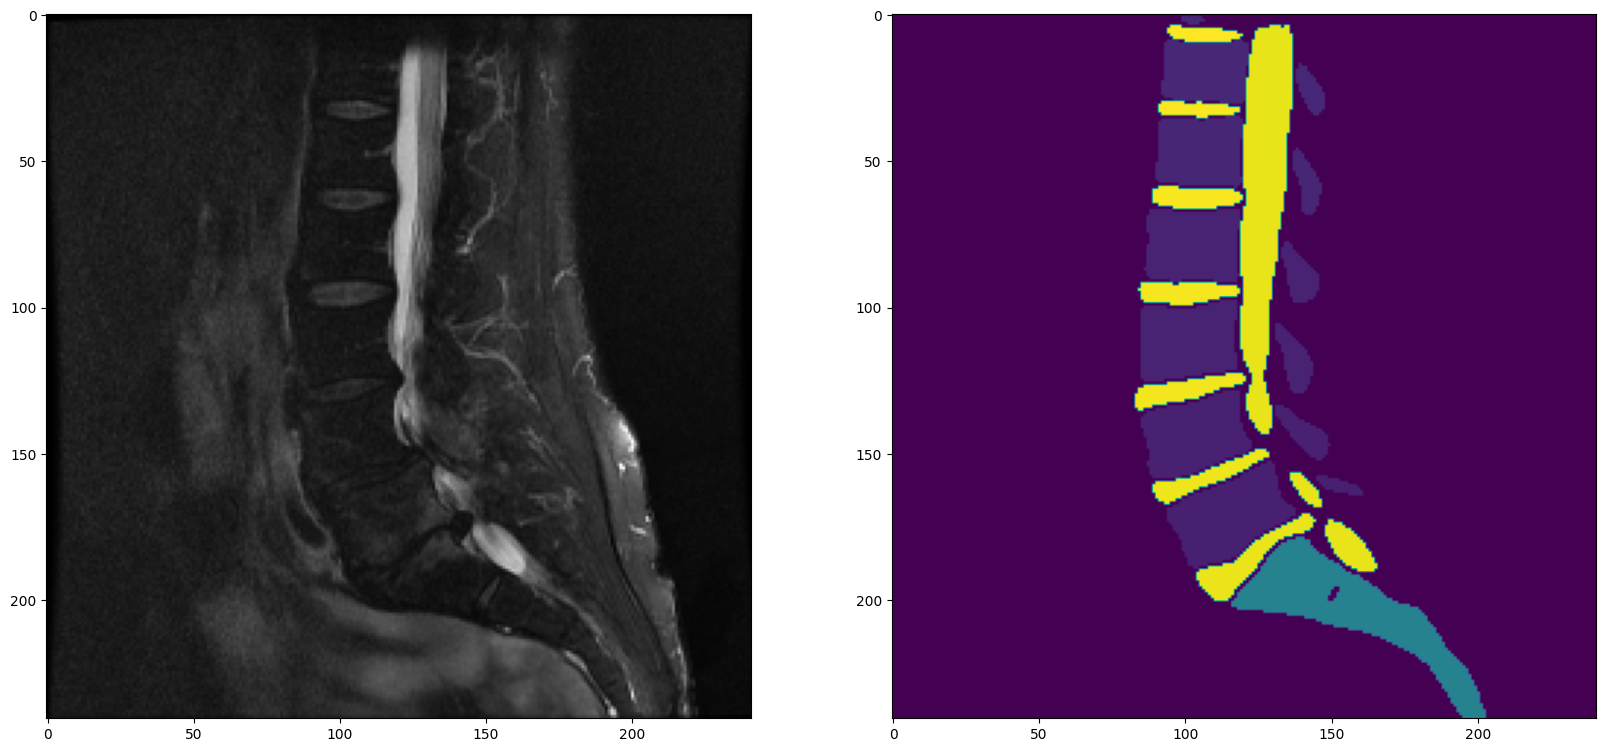

In [24]:
idx = 35
fig, ax = plt.subplots(figsize=(20, 10), ncols=2)
ax[0].imshow(vol[idx], cmap="gray")
ax[1].imshow(seg[idx])
plt.show()

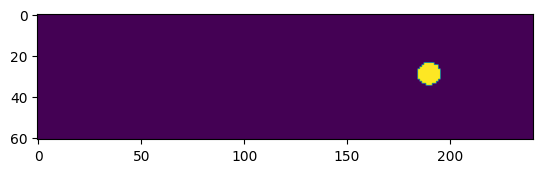

In [25]:
mask = np.isin(seg, [202, 203, 204, 205, 200, 201]).astype(int)
plt.imshow(mask[:,:,167])

In [26]:
discs = np.isin(seg, [202, 203, 204, 205, 206]).astype(int)
disc_l5 = np.isin(seg, [202]).astype(int)
disc_l4 = np.isin(seg, [203]).astype(int)
disc_l3 = np.isin(seg, [204]).astype(int)
disc_l2 = np.isin(seg, [205]).astype(int)
disc_l1 = np.isin(seg, [206]).astype(int)

In [27]:
def patch_extraction(vol, mask, d=0, h=20, w=20):
    """
    Extract a ROI from a volume with a given segmentation mask.

    vol : array of shape (D, H, W)
    mask : segmentation mask of shape (D, H, W)
    d, h, w : margin for each image axis
    """
    
    D, H, W = vol.shape
    mask = torch.Tensor(mask)
    nonzero_indices = torch.nonzero(mask)  # Extracting non-zero indices from the first channel

    d_min, h_min, w_min = nonzero_indices.min(0)[0]  # Minimum indices
    d_max, h_max, w_max = nonzero_indices.max(0)[0]  # Maximum indices
    
    patch = vol[max(0, d_min-d):min(D, d_max + d), 
                max(0, h_min - h):min(H, h_max + h), 
                max(0, w_min - w):min(W, w_max + w)]

    return patch

(39, 48, 72)
(41, 49, 75)
(44, 53, 79)
(52, 60, 79)
(58, 70, 80)


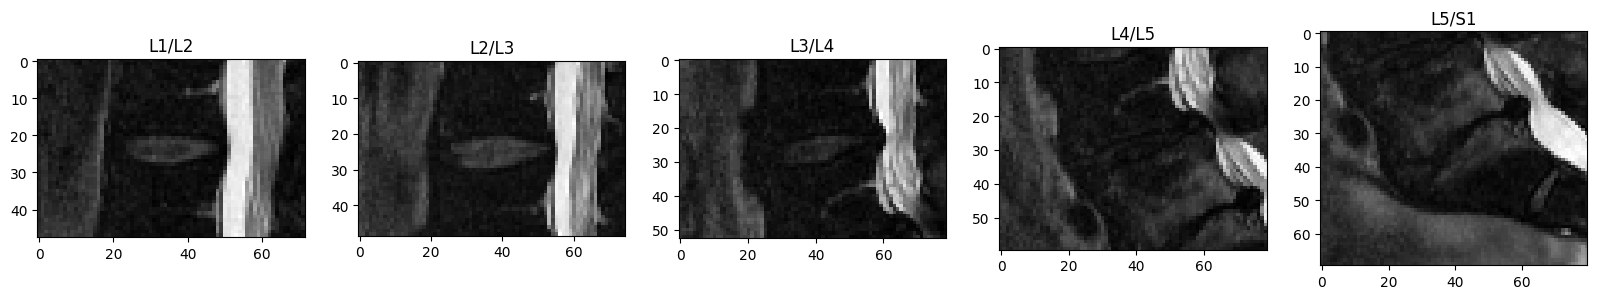

In [28]:
discs = np.isin(seg, [202, 203, 204, 205, 206]).astype(int)
disc_l5 = np.isin(seg, [202]).astype(int)
disc_l4 = np.isin(seg, [203]).astype(int)
disc_l3 = np.isin(seg, [204]).astype(int)
disc_l2 = np.isin(seg, [205]).astype(int)
disc_l1 = np.isin(seg, [206]).astype(int)

discs = [disc_l1, disc_l2, disc_l3, disc_l4, disc_l5]
levels = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]

fig, ax = plt.subplots(ncols=5, figsize=(20, 10))

D, H, W = vol.shape

for i, disc in enumerate(discs):

    patch = patch_extraction(vol, disc, d=0, h=20, w=20)
    print(patch.shape)
    d, h, w = patch.shape
    ax[i].imshow(patch[d//2], cmap="gray")
    ax[i].set_title(levels[i])

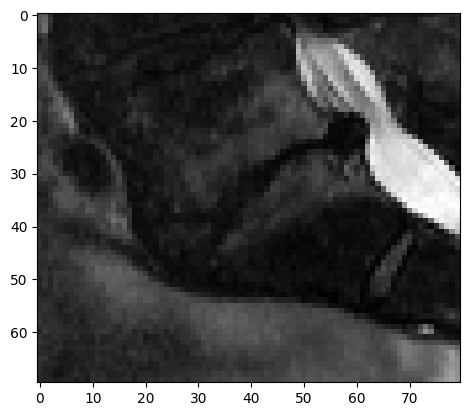

In [29]:
plt.imshow(patch[30,:,:], cmap="gray")
plt.show()

In [30]:
class SpinalCanalStenosisDataset(Dataset):
    def __init__(self, 
                 root_dir : str = "../../TotalSpineSeg",
                 vol_paths : list = None,
                 seg_paths : list = None,
                 labels_csv : str = "../data/train.csv",
                 transform : any = None):
        
        
        text2int = {"Normal/Mild": 0, "Moderate": 1, "Severe": 2}
        vol_paths.sort()
        seg_paths.sort()
        self.vol_paths = vol_paths
        self.seg_paths = seg_paths
        self.transform = transform
        self.root_dir = root_dir
        
        self.labels = pd.read_csv(labels_csv)
        self.labels = self.labels[["study_id",
                                   "spinal_canal_stenosis_l1_l2",
                                   "spinal_canal_stenosis_l2_l3",
                                   "spinal_canal_stenosis_l3_l4",
                                   "spinal_canal_stenosis_l4_l5",
                                   "spinal_canal_stenosis_l5_s1"]]
        self.labels = self.labels.replace(text2int)
        
    def __len__(self):
        return len(self.vol_paths)
        
    def __getitem__(self, idx):
        
        vol_path = self.vol_paths[idx]
        x = vol_path.split("/")[-1]
        x = x[:-7]+"_0000.nii.gz"
        
        
        study_id = x.split("_")[0][4:]
        
        seg_path = self.seg_paths[idx]
        
        label = self.labels[self.labels["study_id"]==int(study_id)].values[0,1:].astype(int)
        
        vol = Image(path+"/output/input/"+x)
        vol.change_orientation("LSA")
        vol = vol.data
        seg = Image(seg_path)
        seg.change_orientation("LSA")
        seg = seg.data
        
        D, H, W = vol.shape
        discs = np.isin(seg, [202, 203, 204, 205, 206]).astype(int)
        disc_l5 = np.isin(seg, [202]).astype(int)
        disc_l4 = np.isin(seg, [203]).astype(int)
        disc_l3 = np.isin(seg, [204]).astype(int)
        disc_l2 = np.isin(seg, [205]).astype(int)
        disc_l1 = np.isin(seg, [206]).astype(int)
        spinal_canal = np.isin(seg, [201]).astype(int)

        discs = [disc_l1, disc_l2, disc_l3, disc_l4, disc_l5]
        levels = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]
        patches = {}
        patches_seg = {}
        
        for i, disc in enumerate(discs):
            patch = patch_extraction(vol, disc, d=0, h=20, w=20).copy()
            patch_seg = patch_extraction(spinal_canal, disc, d=0, h=20, w=20).copy()
            patches[levels[i]] = torch.Tensor(patch[None])
            patches_seg[levels[i]] = torch.Tensor(patch_seg[None])
                
        if self.transform is not None:
            patches = self.transform(patches)
            patches_seg = self.transform(patches_seg)
        
        return patches, patches_seg, label       

In [38]:
transform = Compose(
    [
        ResizeWithPadOrCropd(keys=["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"],
                             spatial_size=(4, 64, 64)),
        ScaleIntensityRangePercentilesd(keys=["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"],
                                        lower=5, upper=95, b_min=1, b_max=10)
    ]    
)

root_dir="../../TotalSpineSeg"
vol_paths = glob.glob(root_dir + "/data/sub*T2w.nii.gz")
seg_paths = glob.glob(root_dir+"/output/step2_output/*T2w.nii.gz")

vol_paths.sort()
seg_paths.sort()

# train_vols, val_vols, train_seg, val_seg = train_test_split(vol_paths, seg_paths, test_size=0.3)

dataset = SpinalCanalStenosisDataset(
    vol_paths=vol_paths, 
    seg_paths=seg_paths, 
    transform=transform
)

len(dataset)

1935

[0 0 0 0 0]
[0 1 1 2 0]
[0 0 1 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 1 1 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 2 0 0]


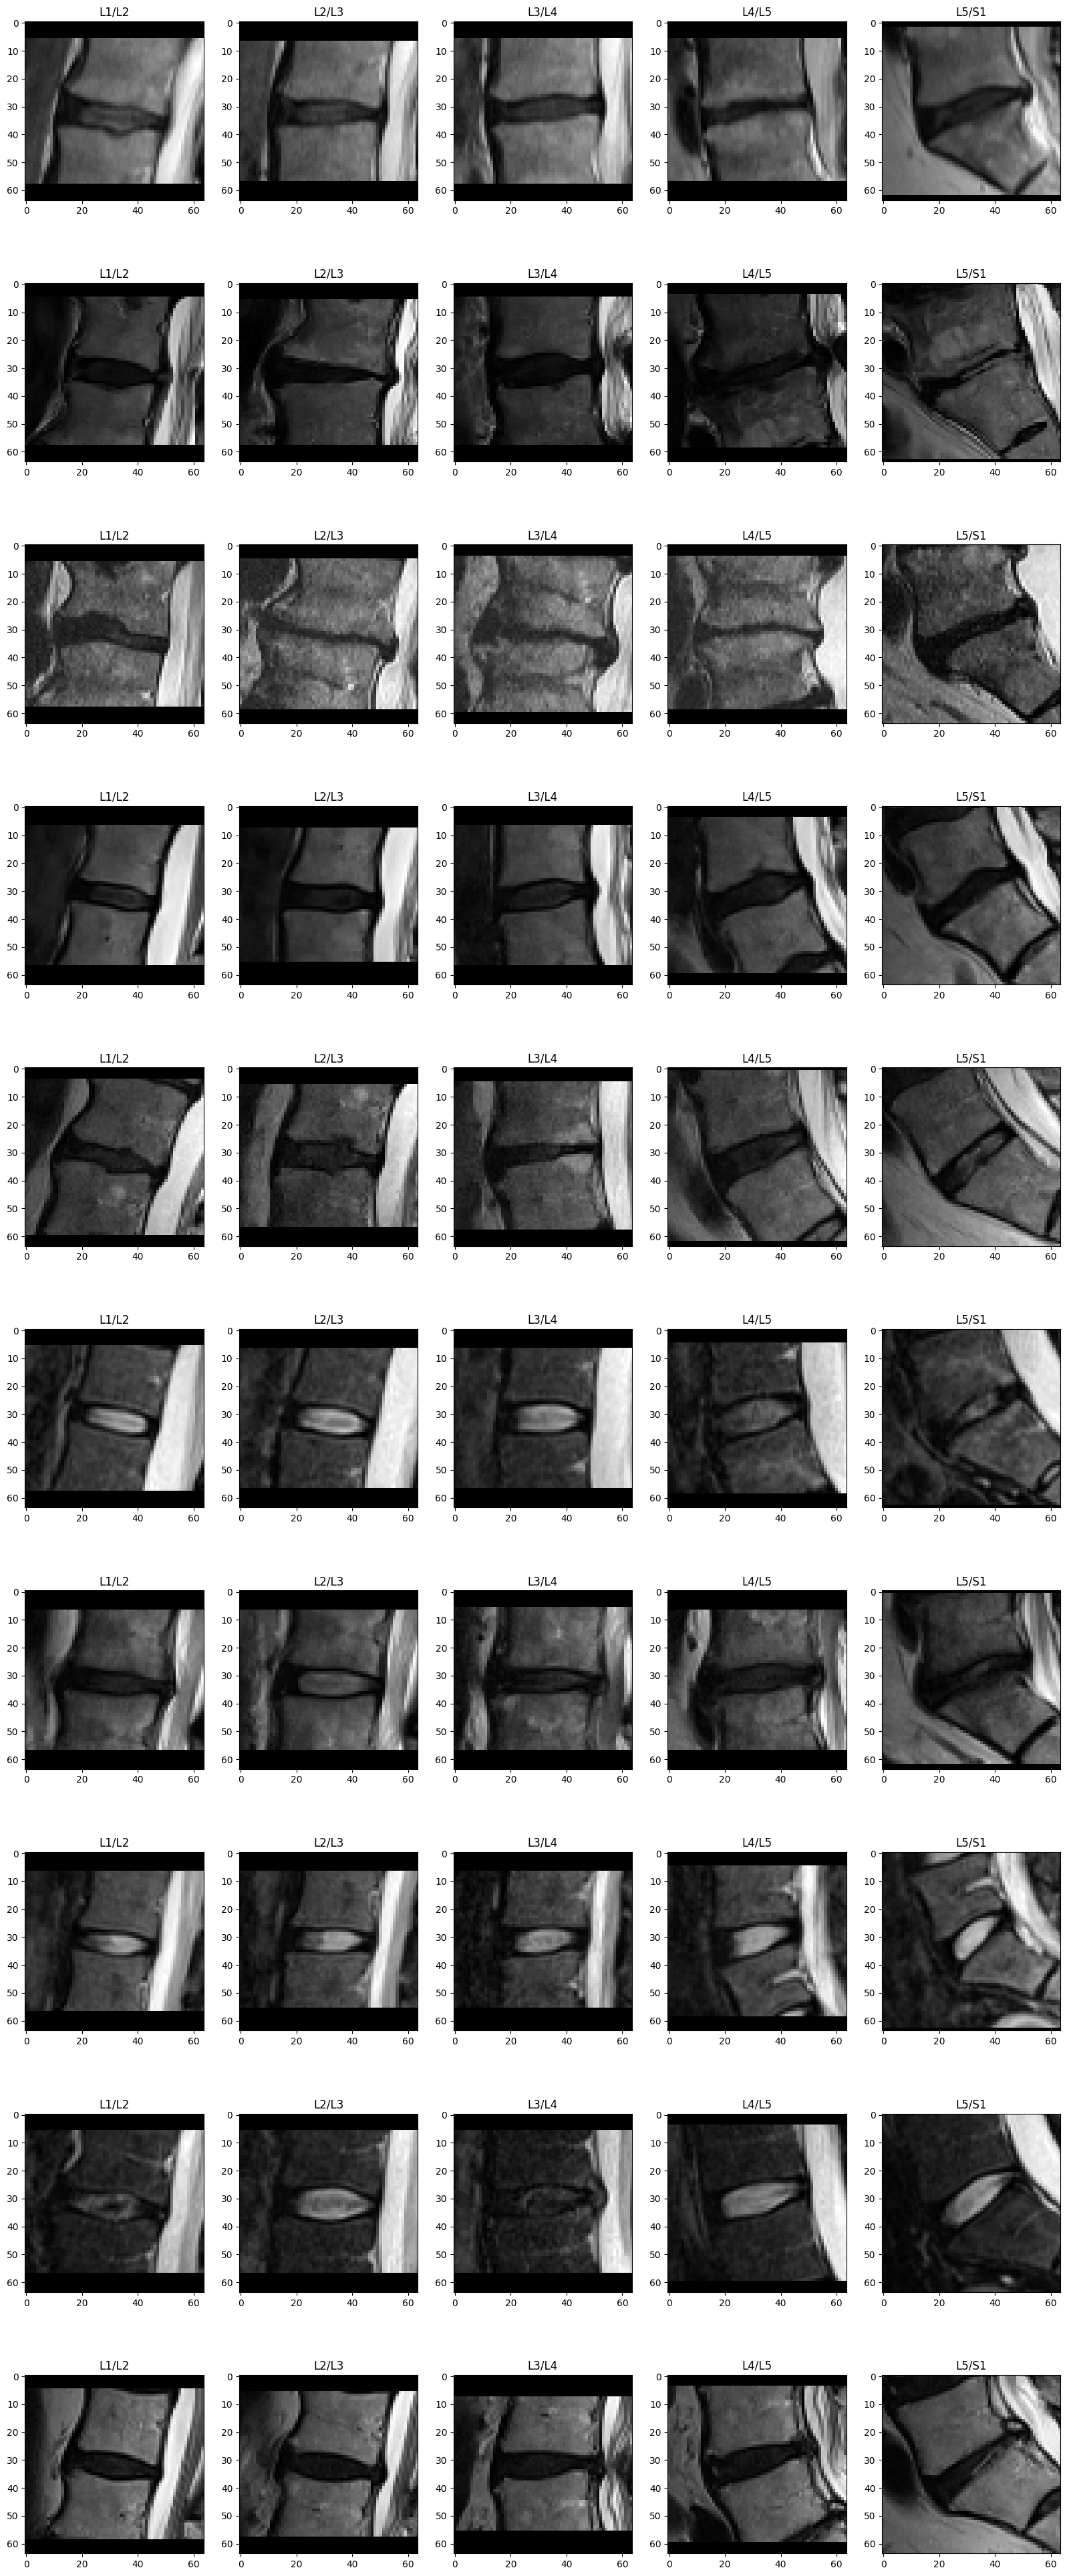

In [39]:
levels = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]
fig, ax = plt.subplots(nrows=10, ncols=5, figsize=(20, 50))

for k in range(10):
    patches, patches_seg, label = dataset.__getitem__(np.random.randint(len(dataset)))
    print(label)
    for i, level in enumerate(levels):
        patch = patches[level]
        patch_seg = patches_seg[level]
        c, d, h, w = patch.shape
        # ax[k, i].imshow(torch.cat((patch[0, d//2], patch_seg[0, d//2]), dim=1), cmap="gray")
        ax[k, i].imshow(patch[0, d//2], cmap="gray")
        ax[k, i].set_title(levels[i])
        # ax[k, i].hist(patch.ravel(), bins="auto", edgecolor="k")

In [15]:
loader = DataLoader(dataset)

In [16]:
_, _, label = next(iter(loader))

In [17]:
def patch_extraction2(vol, mask, d=10, h=20, w=20):
    """
    Extract a ROI from a volume with a given segmentation mask.

    vol : array of shape (D, H, W)
    mask : segmentation mask of shape (D, H, W)
    d, h, w : margin for each image axis
    """
    
    D, H, W = vol.shape
    mask = torch.Tensor(mask)
    nonzero_indices = torch.nonzero(mask)  # Extracting non-zero indices from the first channel

    d_min, h_min, w_min = nonzero_indices.min(0)[0]  # Minimum indices
    d_max, h_max, w_max = nonzero_indices.max(0)[0]  # Maximum indices
    
    disc_length = d_max - d_min
    
    patch1 = vol[max(0, d_min+int(0.15*disc_length)):min(D, d_min+int(0.3*disc_length)), 
                max(0, h_min - h):min(H, h_max + h), 
                max(0, w_min - w):min(W, w_max + w)]
    
    patch2 = vol[max(0, d_max-int(0.3*disc_length)):min(D, d_max-int(0.15*disc_length)), 
                max(0, h_min - h):min(H, h_max + h), 
                max(0, w_min - w):min(W, w_max + w)]

    return patch1, patch2

In [24]:
class ForaminalNarrowingDataset(Dataset):
    def __init__(self, 
                 root_dir : str = "../../TotalSpineSeg",
                 vol_paths : list = None,
                 seg_paths : list = None,
                 labels_csv : str = "../data/train.csv",
                 transform : any = None):
        
        
        text2int = {"Normal/Mild": 0, "Moderate": 1, "Severe": 2}
        vol_paths.sort()
        seg_paths.sort()
        self.vol_paths = vol_paths
        self.seg_paths = seg_paths
        self.transform = transform
        self.root_dir = root_dir
        
        self.labels = pd.read_csv(labels_csv)
        self.labels = self.labels[["study_id",
                                   "right_neural_foraminal_narrowing_l1_l2",
                                   "right_neural_foraminal_narrowing_l2_l3",
                                   "right_neural_foraminal_narrowing_l3_l4",
                                   "right_neural_foraminal_narrowing_l4_l5",
                                   "right_neural_foraminal_narrowing_l5_s1",
                                   "left_neural_foraminal_narrowing_l1_l2",
                                   "left_neural_foraminal_narrowing_l2_l3",
                                   "left_neural_foraminal_narrowing_l3_l4",
                                   "left_neural_foraminal_narrowing_l4_l5",
                                   "left_neural_foraminal_narrowing_l5_s1"]]
        
        self.labels = self.labels.replace(text2int)
        
    def __len__(self):
        return len(self.vol_paths)
        
    def __getitem__(self, idx):
        
        vol_path = self.vol_paths[idx]
        x = vol_path.split("/")[-1]
        x = x[:-7]+"_0000.nii.gz"
        
        
        study_id = x.split("_")[0][4:]
        
        seg_path = self.seg_paths[idx]
        
        label = self.labels[self.labels["study_id"]==int(study_id)].values[0,1:].astype(int)
        
        vol = Image(self.root_dir+"/output/input/"+x)
        vol.change_orientation("LSA")
        vol = vol.data

        seg = Image(seg_path)
        seg = seg.change_orientation("LSA")
        seg = seg.data
        
        D, H, W = vol.shape
        discs = np.isin(seg, [202, 203, 204, 205, 206]).astype(int)
        disc_l5 = np.isin(seg, [202]).astype(int)
        disc_l4 = np.isin(seg, [203]).astype(int)
        disc_l3 = np.isin(seg, [204]).astype(int)
        disc_l2 = np.isin(seg, [205]).astype(int)
        disc_l1 = np.isin(seg, [206]).astype(int)
        spinal_canal = np.isin(seg, [201]).astype(int)

        discs = [disc_l1, disc_l2, disc_l3, disc_l4, disc_l5]
        levels = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]
        patches_left, patches_right = {}, {}
        
        w = 20
        for i, disc in enumerate(discs):
            patch_r, patch_l = patch_extraction2(vol, disc, d=16, h=40, w=20)
            patches_left[levels[i]] = torch.Tensor(patch_l[None].copy())
            patches_right[levels[i]] = torch.Tensor(patch_r[None].copy())
                
        if self.transform is not None:
            patches_left = self.transform(patches_left)
            patches_right = self.transform(patches_right)
        
        return patches_left, patches_right, label       

In [25]:
transform = Compose(
    [
        # HistogramNormalized(keys=["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]),
        ResizeWithPadOrCropd(keys=["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"],
                             spatial_size=(4, 48, 96)),
    ]    
)

root_dir="../../TotalSpineSeg"
vol_paths = glob.glob(root_dir + "/data/sub*T1w.nii.gz")
seg_paths = glob.glob(root_dir + "/output/step2_output/*T1w.nii.gz")

vol_paths.sort()
seg_paths.sort()

# train_vols, val_vols, train_seg, val_seg = train_test_split(vol_paths, seg_paths, test_size=0.3)

dataset = ForaminalNarrowingDataset(root_dir=root_dir, vol_paths=vol_paths, seg_paths=seg_paths, transform=transform)
len(dataset)

1942

[0 0 0 0 0 1 0 0 1 0]
[0 0 0 1 0 0 0 0 0 2]
[0 0 0 0 0 0 0 0 1 0]
[0 0 0 0 0 0 0 0 0 0]


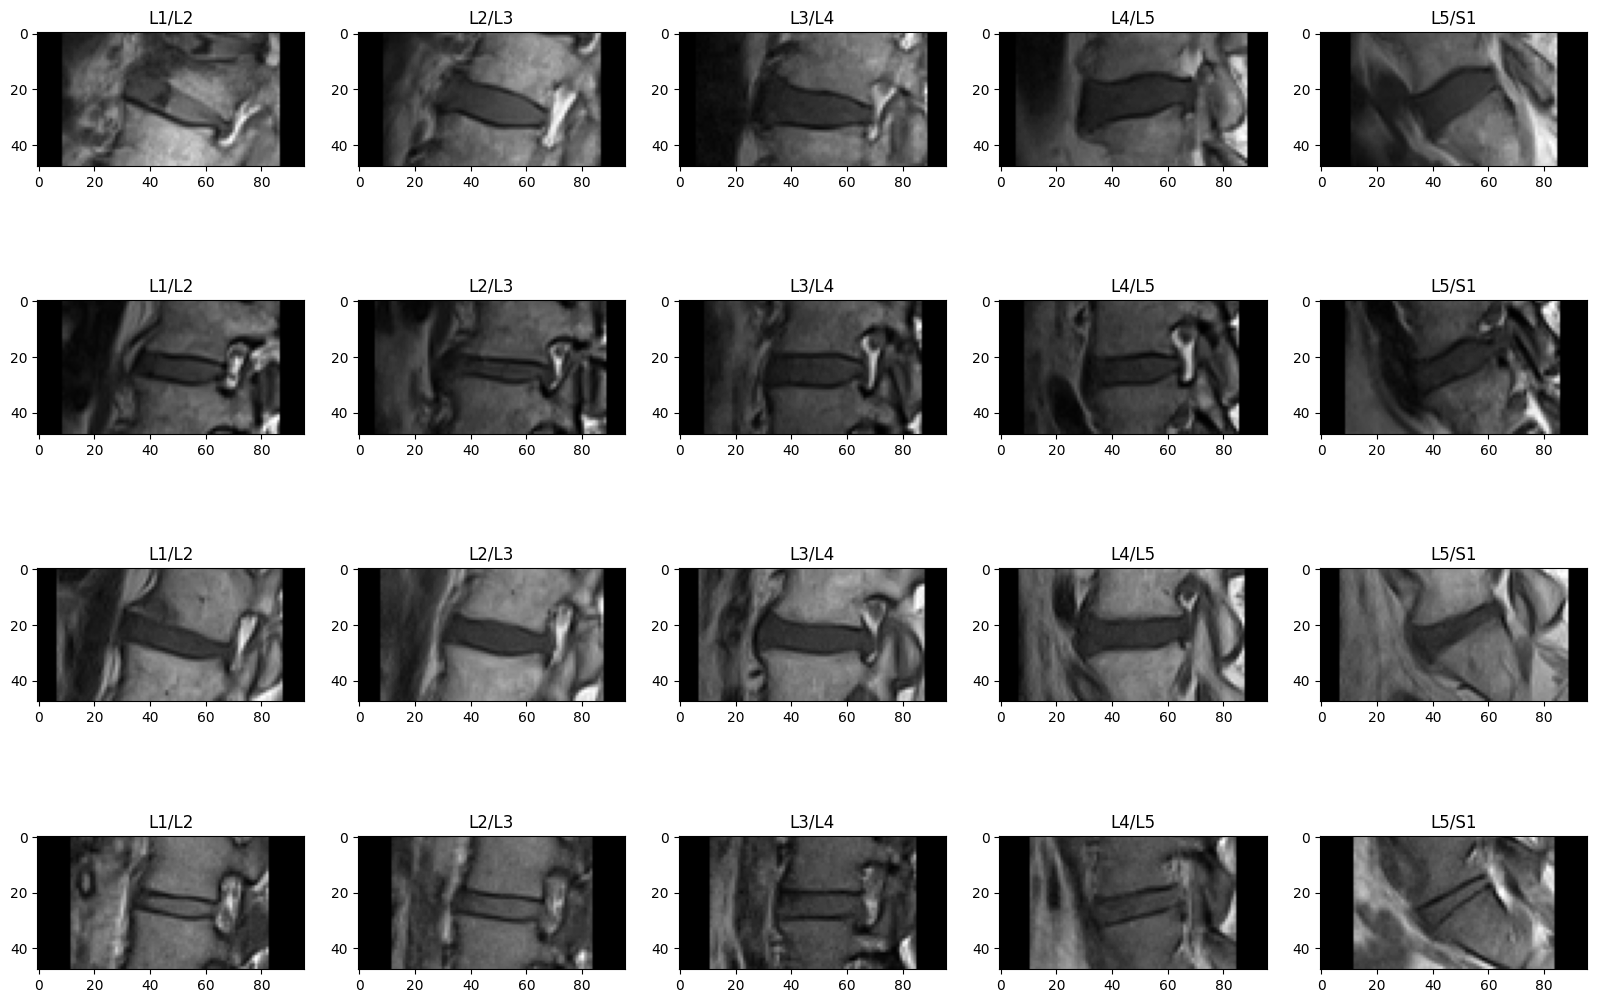

In [26]:
levels = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]
nrows = 4
fig, ax = plt.subplots(nrows=nrows, ncols=5, figsize=(20, nrows*10/3))

for k in range(nrows):
    patches_left, patches_right, label = dataset.__getitem__(np.random.randint(1354))
    print(label)
    for i, level in enumerate(levels):
        patch = patches_right[level]
        c, d, h, w = patch.shape
        # print(c, d, h, w)
        ax[k, i].imshow(patch[0, d//2], cmap="gray")
        ax[k, i].set_title(levels[i])

In [21]:
batch_data = next(iter(dataset))

In [22]:
patches, _, _ = batch_data

In [23]:
img = patches["L1/L2"]